# Task 3: Cross-Country Climate Comparison & Vulnerability Ranking

This analysis compares Ethiopia, Kenya, Tanzania, Sudan, and Nigeria to evaluate climate vulnerability using temperature trends, precipitation patterns, and extreme weather indicators. The goal is to support Ethiopia’s COP32 positioning.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")

In [7]:
ethiopia["Country"] = "Ethiopia"
kenya["Country"] = "Kenya"
tanzania["Country"] = "Tanzania"
sudan["Country"] = "Sudan"
nigeria["Country"] = "Nigeria"

In [8]:
df = pd.concat([ethiopia, kenya, tanzania, sudan, nigeria])

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,MONTH
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1.0
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1.0
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1.0
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1.0
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1.0


In [10]:
df.columns

Index(['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR',
       'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'Country', 'DATE', 'MONTH'],
      dtype='str')

In [12]:
df["year"] = df["YEAR"]
df["month"] = df["MONTH"]

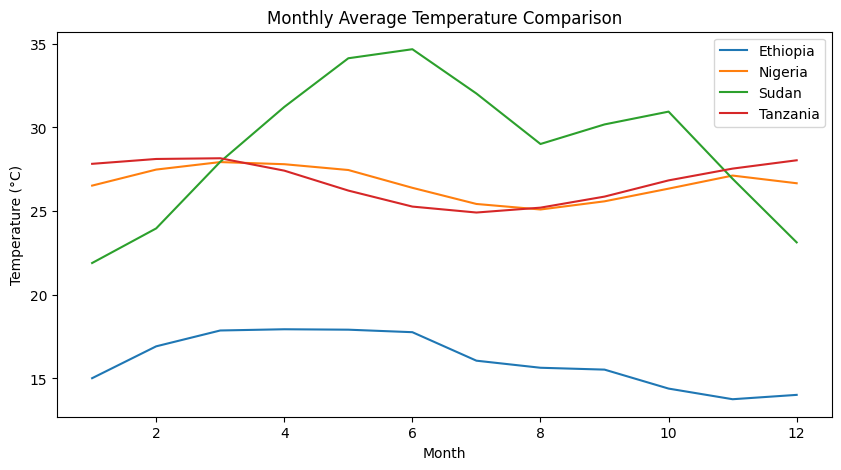

In [13]:
monthly_temp = df.groupby(["Country", "month"])["T2M"].mean().reset_index()

plt.figure(figsize=(10,5))

for c in monthly_temp["Country"].unique():
    temp = monthly_temp[monthly_temp["Country"] == c]
    plt.plot(temp["month"], temp["T2M"], label=c)

plt.title("Monthly Average Temperature Comparison")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

In [14]:
df.groupby("Country")["T2M"].agg(["mean","median","std"])

,mean,median,std
Country,,,
Ethiopia,16.068500,16.04,1.898050
Kenya,20.427600,20.36,1.440824
Nigeria,26.656928,26.82,1.123335
Sudan,28.759007,29.16,4.681305
Tanzania,26.802422,26.99,1.325388


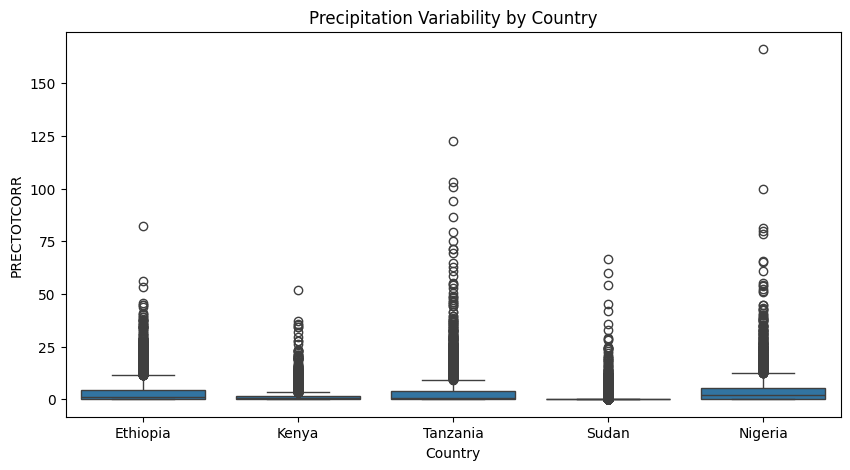

In [15]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="Country", y="PRECTOTCORR")
plt.title("Precipitation Variability by Country")
plt.show()

In [16]:
df.groupby("Country")["PRECTOTCORR"].agg(["mean","median","std"])

,mean,median,std
Country,,,
Ethiopia,3.633795,0.82,6.289061
Kenya,1.468162,0.38,3.180228
Nigeria,4.213914,1.84,7.266742
Sudan,0.643875,0.00,3.057672
Tanzania,3.740256,0.64,8.003947


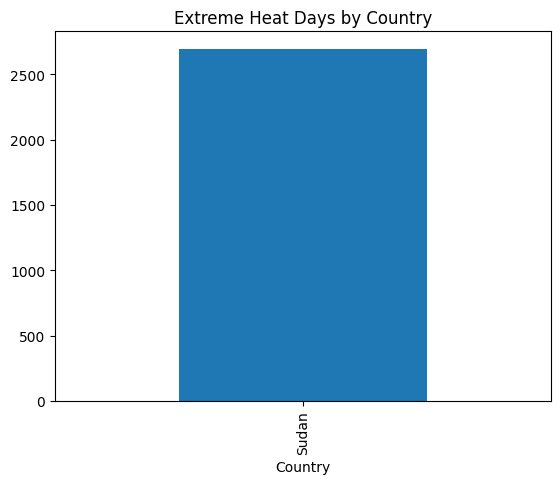

In [17]:
extreme_heat = df[df["T2M_MAX"] > 35].groupby("Country").size()

extreme_heat.plot(kind="bar", title="Extreme Heat Days by Country")
plt.show()

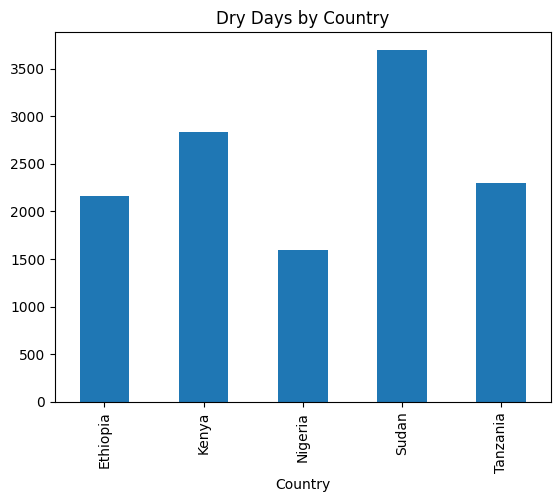

In [18]:
drought = df[df["PRECTOTCORR"] < 1].groupby("Country").size()

drought.plot(kind="bar", title="Dry Days by Country")
plt.show()

In [19]:
ranking = df.groupby("Country").agg({
    "T2M": "std",
    "PRECTOTCORR": "std"
})

ranking["Vulnerability_Score"] = ranking["T2M"] + ranking["PRECTOTCORR"]

ranking.sort_values("Vulnerability_Score", ascending=False)

,T2M,PRECTOTCORR,Vulnerability_Score
Country,,,
Tanzania,1.325388,8.003947,9.329335
Nigeria,1.123335,7.266742,8.390077
Ethiopia,1.898050,6.289061,8.187111
Sudan,4.681305,3.057672,7.738977
Kenya,1.440824,3.180228,4.621052


## COP32 Key Insights

- Countries with higher temperature variability show stronger climate stress and warming patterns.
- Precipitation instability highlights risk in agriculture and water security.
- Extreme heat frequency indicates increasing health and environmental risks.
- Ethiopia’s climate profile shows moderate vulnerability compared to regional peers.
- These findings support targeted climate finance allocation based on vulnerability ranking.